In [7]:
import  numpy as np
import pandas as pd
import scipy
from scipy import stats
from collections import Counter
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import norm
from scipy.stats import t,expon
from collections import Counter

In [2]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

# CLEANING DATA

In [35]:
df=pd.read_excel("data1.xlsx")

In [36]:
df.shape

(500, 1)

In [37]:
df.Category.isnull().sum()

np.int64(80)

In [38]:
np.where(df.Category.isnull())

(array([  9,  11,  15,  32,  35,  38,  47,  48,  58,  59,  62,  64,  80,
         81,  82,  84,  95,  98, 122, 123, 140, 156, 161, 163, 164, 165,
        166, 167, 170, 174, 176, 177, 188, 192, 193, 212, 217, 223, 227,
        231, 237, 238, 246, 248, 250, 254, 257, 260, 267, 268, 269, 278,
        281, 287, 303, 328, 329, 333, 342, 345, 349, 357, 382, 384, 387,
        404, 406, 441, 445, 447, 451, 456, 459, 464, 471, 476, 477, 490,
        492, 494]),)

In [39]:
80/df.shape[0]

0.16

In [40]:
Counter(df.Category).most_common()  

[('B', 113), ('A', 112), ('C', 101), ('D', 94), (nan, 80)]

In [43]:
df.Category.value_counts()

Category
B    113
A    112
C    101
D     94
Name: count, dtype: int64

**Filling the missing values with Mode **Categorical Data****

In [42]:
#df.Category.fillna("B",inplace=True) #Filling the Missing with the mode

In [44]:
props=pd.DataFrame(df.Category.value_counts())

In [45]:
props["Proportion"]=props["count"]/sum(props["count"])

In [46]:
props

,count,Proportion
Category,,
B,113,0.269048
A,112,0.266667
C,101,0.240476
D,94,0.223810


In [50]:
random_values=np.random.choice(["A","B","C","D"],size=80,p=props.Proportion)

In [51]:
random_values

array(['B', 'B', 'A', 'C', 'B', 'A', 'D', 'A', 'C', 'D', 'B', 'C', 'D',
       'C', 'C', 'D', 'D', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'A',
       'D', 'D', 'B', 'D', 'A', 'B', 'D', 'A', 'A', 'C', 'B', 'B', 'C',
       'B', 'A', 'D', 'D', 'D', 'C', 'D', 'B', 'B', 'A', 'C', 'B', 'C',
       'B', 'D', 'C', 'B', 'A', 'B', 'B', 'A', 'C', 'B', 'B', 'D', 'A',
       'A', 'B', 'B', 'D', 'B', 'D', 'D', 'D', 'B', 'C', 'B', 'A', 'D',
       'B', 'B'], dtype='<U1')

In [57]:
ind=np.where(df.Category.isnull())
ind

(array([  9,  11,  15,  32,  35,  38,  47,  48,  58,  59,  62,  64,  80,
         81,  82,  84,  95,  98, 122, 123, 140, 156, 161, 163, 164, 165,
        166, 167, 170, 174, 176, 177, 188, 192, 193, 212, 217, 223, 227,
        231, 237, 238, 246, 248, 250, 254, 257, 260, 267, 268, 269, 278,
        281, 287, 303, 328, 329, 333, 342, 345, 349, 357, 382, 384, 387,
        404, 406, 441, 445, 447, 451, 456, 459, 464, 471, 476, 477, 490,
        492, 494]),)

In [59]:
df.loc[ind[0],"Category"]=random_values

In [61]:
df.Category.isnull().sum()

np.int64(0)

**Replacing the Missing Values in Continious data**

In [64]:
df1=pd.read_excel("data2.xlsx")

In [65]:
df1.head()

,Category,Continuous_Value
0,C,-4008.098297
1,D,-3887.888132
2,NaN,-3712.188312
3,C,-3416.823821
4,D,-5845.073897


In [66]:
df1.Continuous_Value=df1.Continuous_Value.fillna(df1.Continuous_Value.median())

In [67]:
df1.head()

,Category,Continuous_Value
0,C,-4008.098297
1,D,-3887.888132
2,NaN,-3712.188312
3,C,-3416.823821
4,D,-5845.073897


# GRAPH PLOTTING


<BarContainer object of 5 artists>

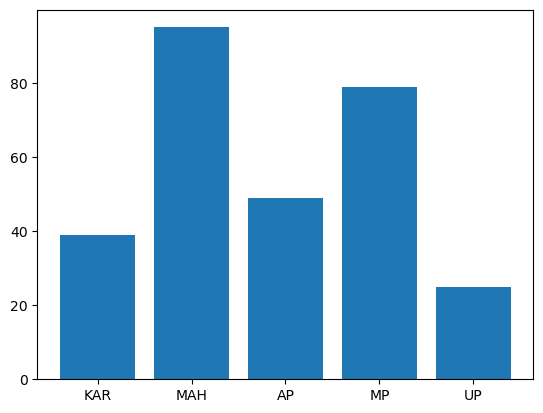

In [6]:
states=["KAR","MAH","AP","MP","UP"]
count=[39,95,49,79,25]

plt.bar(states,count) # Bar Chart


<Axes: >

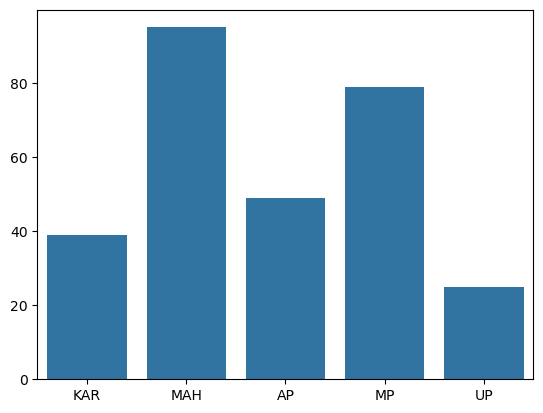

In [38]:
sns.barplot(x=states,y=count) # seaborn bar plot

In [8]:
df=pd.read_excel("CDAC_DataBook.xlsx",sheet_name="ERPData")

In [9]:
df.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


In [15]:
df1=df.MaterialID.value_counts()
df1

MaterialID
TMI-43T    15
AXCP-78    11
DDBN-89     8
SDRT-67     6
LXCV-21     5
GCVB-79     5
Name: count, dtype: int64

<BarContainer object of 6 artists>

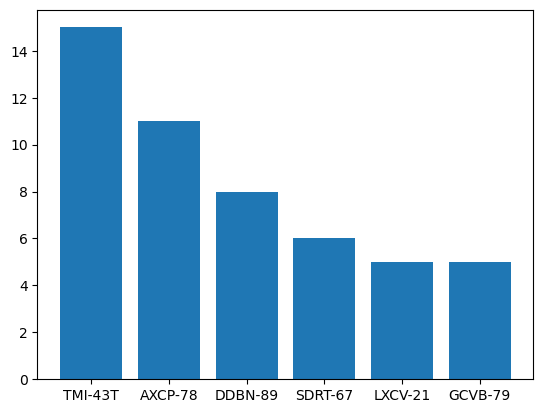

In [19]:
plt.bar(df1.index,df1)

<Axes: xlabel='MaterialID', ylabel='count'>

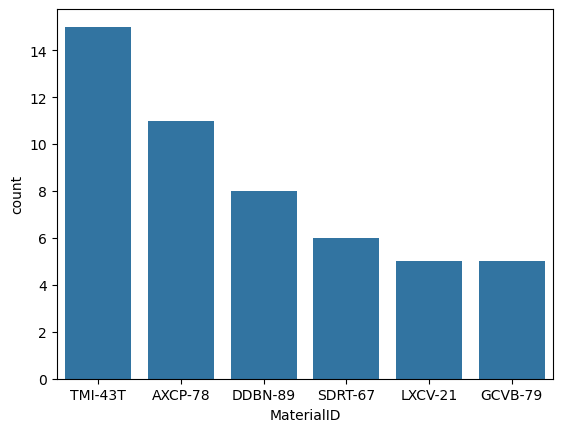

In [41]:

sns.barplot(x=df1.index,y=df1)

In [42]:
df2=df.Location.value_counts()

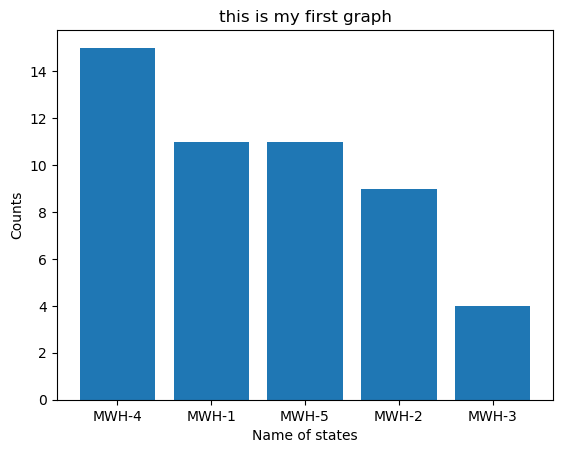

In [44]:
plt.bar(df2.index,df2)
plt.title("this is my first graph")
plt.xlabel("Name of states")
plt.ylabel("Counts")
plt.show()



In [26]:
grp1=df.groupby("MaterialID")
grp1.groups

{'AXCP-78': [1, 3, 4, 24, 25, 37, 38, 39, 46, 47, 48], 'DDBN-89': [22, 23, 26, 30, 40, 43, 45, 49], 'GCVB-79': [8, 15, 34, 35, 36], 'LXCV-21': [2, 27, 28, 29, 44], 'SDRT-67': [10, 11, 16, 17, 41, 42], 'TMI-43T': [0, 5, 6, 7, 9, 12, 13, 14, 18, 19, 20, 21, 31, 32, 33]}

In [32]:
df3=grp1.Quantity.agg("sum")
df3

MaterialID
AXCP-78    898
DDBN-89    383
GCVB-79    182
LXCV-21    243
SDRT-67    294
TMI-43T    885
Name: Quantity, dtype: int64

<BarContainer object of 6 artists>

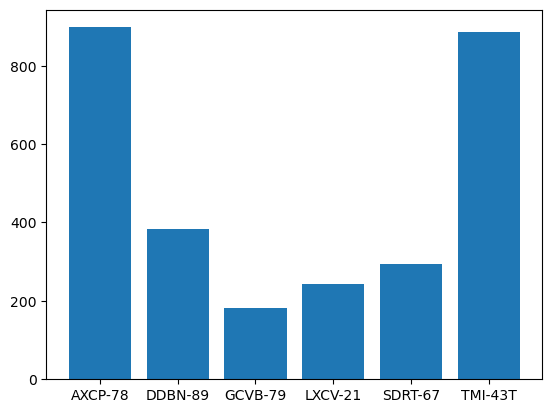

In [36]:
plt.bar(df3.index,df3)

In [53]:
df4=pd.crosstab(df.Location,df.MaterialID) # frequency of each material id in particular location
df4 

MaterialID,AXCP-78,DDBN-89,GCVB-79,LXCV-21,SDRT-67,TMI-43T
Location,,,,,,
MWH-1,5,3,0,0,2,1
MWH-2,1,1,4,1,1,1
MWH-3,1,1,0,1,0,1
MWH-4,1,2,0,0,1,11
MWH-5,3,1,1,3,2,1


<Axes: xlabel='Location'>

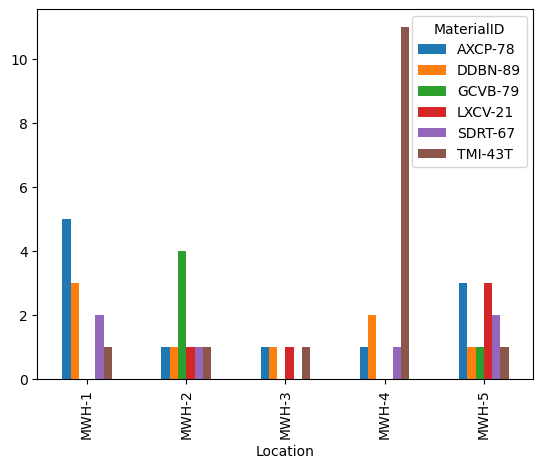

In [54]:
df4.plot(kind="bar")

## nominal dataset

In [56]:
df=pd.read_excel("CDAC_DataBook.xlsx",sheet_name="nominal")

In [57]:
df.head()

,ses,write,math,prog
0,1,35,41,1
1,2,33,41,2
2,3,39,44,3
3,1,37,42,1
4,2,31,40,2


In [58]:
df1=pd.crosstab(df.ses,df.prog)

In [59]:
df1

prog,1,2,3
ses,,,
1,29,16,2
2,6,51,38
3,1,9,48


<Axes: xlabel='ses'>

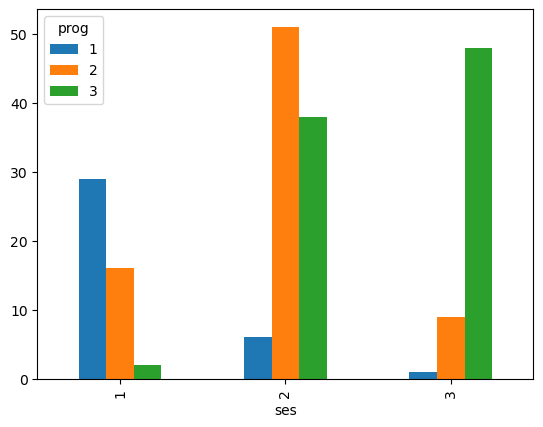

In [61]:
df1.plot(kind="bar")

In [62]:
df=pd.read_excel("CDAC_DataBook.xlsx",sheet_name="ERPData")

{'whiskers': [<matplotlib.lines.Line2D at 0x18fffc85090>,
 'caps': [<matplotlib.lines.Line2D at 0x18fffc85310>,
 'boxes': [<matplotlib.lines.Line2D at 0x18fffc84f50>],
 'medians': [<matplotlib.lines.Line2D at 0x18fffc85590>],
 'fliers': [<matplotlib.lines.Line2D at 0x18fffc856d0>],
 'means': []}

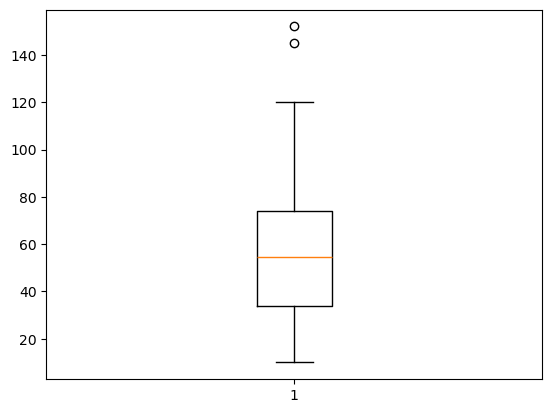

In [64]:
plt.boxplot(df.Quantity)  ## Box Plot 


In [82]:

male_sal=[100,105,9,90,8,5,6,5,6,6]
femal_sal=[80,1,20,30,6,5,6,58,8,98,65,9,59,55,90,8,85,85,96,50,85,9,85,28,7,96,52,200]

{'whiskers': [<matplotlib.lines.Line2D at 0x18f81a51310>,
 'caps': [<matplotlib.lines.Line2D at 0x18f81a51590>,
 'boxes': [<matplotlib.lines.Line2D at 0x18f81a511d0>,
 'medians': [<matplotlib.lines.Line2D at 0x18f81a51810>,
 'fliers': [<matplotlib.lines.Line2D at 0x18f81a51950>,
 'means': []}

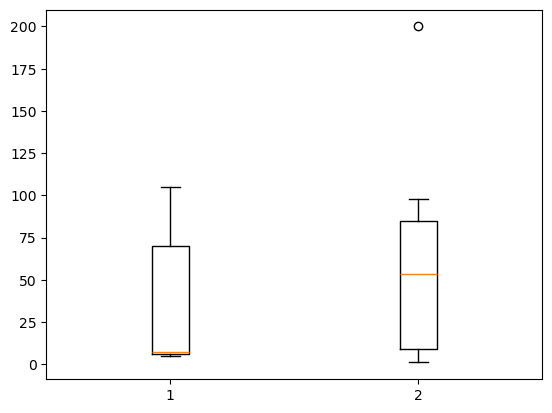

In [83]:
plt.boxplot([male_sal,femal_sal])